# 05. Weekly Retention & 유저 활동성 분석

5주(2/15~3/21) 데이터를 사용하여:
1. **Weekly Cohort Retention** — 첫 활동 주 기준 코호트별 잔존율
2. **유저 활동성 분석** — 활동 일수 분포, 파워유저 vs 캐주얼, 이벤트 패턴

## 1. 데이터 로드

In [1]:
%%time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from gharchive.transform import optimize_types

DATA_DIR = Path("/Users/kakao/bda-2/data/daily_agg")

frames = []
for path in sorted(DATA_DIR.glob("*.parquet")):
    df = pd.read_parquet(path)
    df["date"] = pd.to_datetime(path.stem, format="%Y%m%d")
    frames.append(df)

df = optimize_types(pd.concat(frames, ignore_index=True))

print(f"Rows: {len(df):,}")
print(f"Date range: {df['date'].min().date()} ~ {df['date'].max().date()}")
print(f"Days: {df['date'].nunique()}")
print(f"Unique users: {df['actor_id'].nunique():,}")

Rows: 48,422,013
Date range: 2026-02-15 ~ 2026-03-21


Days: 35


Unique users: 7,028,338
CPU times: user 5.63 s, sys: 1.58 s, total: 7.21 s
Wall time: 6.19 s


## 2. Weekly Cohort Retention

**코호트**: 유저가 처음 활동한 주(Week)
**잔존율**: 코호트 유저 중 N주 뒤에도 활동한 비율

예를 들어 W1 코호트의 Week 2 retention이 40%라면, 첫 주에 처음 나타난 유저 중 40%가 2주차에도 활동했다는 뜻입니다.

In [2]:
%%time
from gharchive.stats import weekly_cohort_retention

retention = weekly_cohort_retention(df)

# 코호트 사이즈도 확인
df["week"] = df["date"].dt.to_period("W-SAT").dt.start_time
cohort_sizes = df.groupby(df.groupby("actor_id")["week"].transform("min"))["actor_id"].nunique()
cohort_sizes.index = cohort_sizes.index.strftime("%m/%d")

print("코호트별 유저 수:")
for idx, size in cohort_sizes.items():
    print(f"  {idx}: {size:>10,}")

print(f"\n총 고유 유저: {df['actor_id'].nunique():,}")
print("\n--- Retention Table (%) ---")
(retention * 100).round(1)

코호트별 유저 수:
  02/15:  2,376,903
  02/22:  1,455,466
  03/01:  1,194,818
  03/08:  1,070,206
  03/15:    930,945



총 고유 유저: 7,028,338

--- Retention Table (%) ---
CPU times: user 33.8 s, sys: 2.37 s, total: 36.2 s
Wall time: 36.9 s


weeks_since,0,1,2,3,4
cohort_week,,,,,
02/15,100.0,46.2,39.7,36.7,33.9
02/22,100.0,32.5,26.6,23.4,0.0
03/01,100.0,29.3,22.1,0.0,0.0
03/08,100.0,26.6,0.0,0.0,0.0
03/15,100.0,0.0,0.0,0.0,0.0


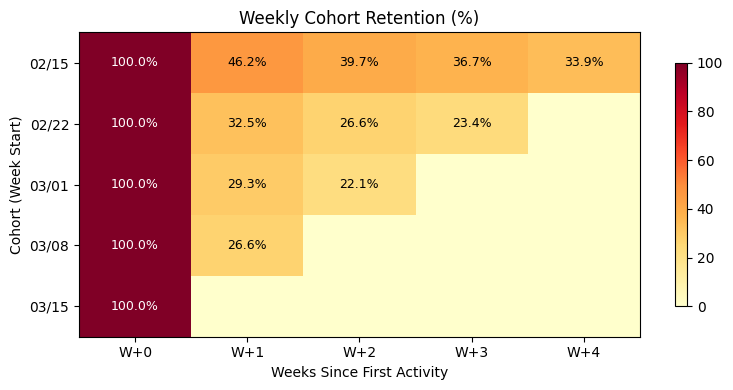

CPU times: user 104 ms, sys: 12.5 ms, total: 116 ms
Wall time: 124 ms


In [3]:
%%time
# Retention 히트맵
fig, ax = plt.subplots(figsize=(8, 4))

data = (retention * 100).values
im = ax.imshow(data, cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)

# 셀 안에 수치 표시
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if val > 0:
            color = "white" if val > 60 else "black"
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=9, color=color)

ax.set_xticks(range(data.shape[1]))
ax.set_xticklabels([f"W+{i}" for i in range(data.shape[1])])
ax.set_yticks(range(data.shape[0]))
ax.set_yticklabels(retention.index)
ax.set_xlabel("Weeks Since First Activity")
ax.set_ylabel("Cohort (Week Start)")
ax.set_title("Weekly Cohort Retention (%)")

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 3. 유저 활동성 분석

유저별로 몇 일 활동했는지, 총 이벤트 수는 얼마인지 요약합니다.

In [4]:
%%time
from gharchive.stats import user_activity_summary

user_stats = user_activity_summary(df)

print(f"총 유저: {len(user_stats):,}")
print(f"\n활동 일수 분포:")
print(user_stats["active_days"].describe().to_string())
print(f"\n총 이벤트 수 분포:")
print(user_stats["total_events"].describe().to_string())

총 유저: 7,028,338

활동 일수 분포:
count    7.028338e+06
mean     3.368697e+00
std      4.550052e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      3.500000e+01

총 이벤트 수 분포:


count      7028338.0
mean       18.144818
std      6601.028289
min              1.0
25%              1.0
50%              3.0
75%              8.0
max       16884892.0
CPU times: user 6min 37s, sys: 3.73 s, total: 6min 41s
Wall time: 6min 42s


<timed exec>:25: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


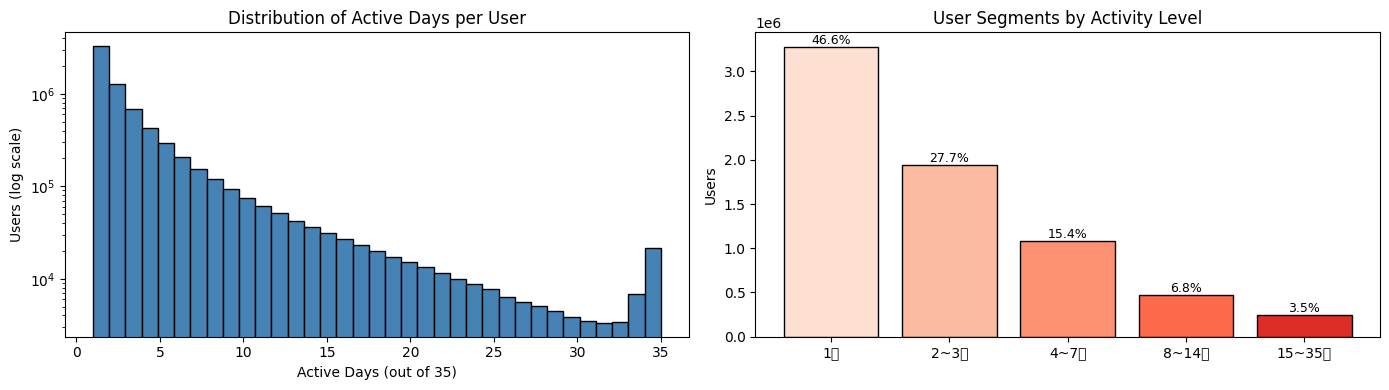

CPU times: user 551 ms, sys: 17.9 ms, total: 569 ms
Wall time: 578 ms


In [5]:
%%time
# 활동 일수 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 활동 일수 분포
axes[0].hist(user_stats["active_days"], bins=35, color="steelblue", edgecolor="black", log=True)
axes[0].set_title("Distribution of Active Days per User")
axes[0].set_xlabel("Active Days (out of 35)")
axes[0].set_ylabel("Users (log scale)")

# 유저 세그먼트 비율
bins = [0, 1, 3, 7, 14, 35]
labels = ["1일", "2~3일", "4~7일", "8~14일", "15~35일"]
user_stats["segment"] = pd.cut(user_stats["active_days"], bins=bins, labels=labels)
segment_counts = user_stats["segment"].value_counts().reindex(labels)

colors = ["#fee0d2", "#fcbba1", "#fc9272", "#fb6a4a", "#de2d26"]
axes[1].bar(labels, segment_counts.values, color=colors, edgecolor="black")
axes[1].set_title("User Segments by Activity Level")
axes[1].set_ylabel("Users")

for i, v in enumerate(segment_counts.values):
    pct = v / len(user_stats) * 100
    axes[1].text(i, v, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 4. 세그먼트별 이벤트 패턴

파워유저(15일+)와 캐주얼 유저(1일)는 어떤 활동을 하는지 비교합니다.

<timed exec>:30: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


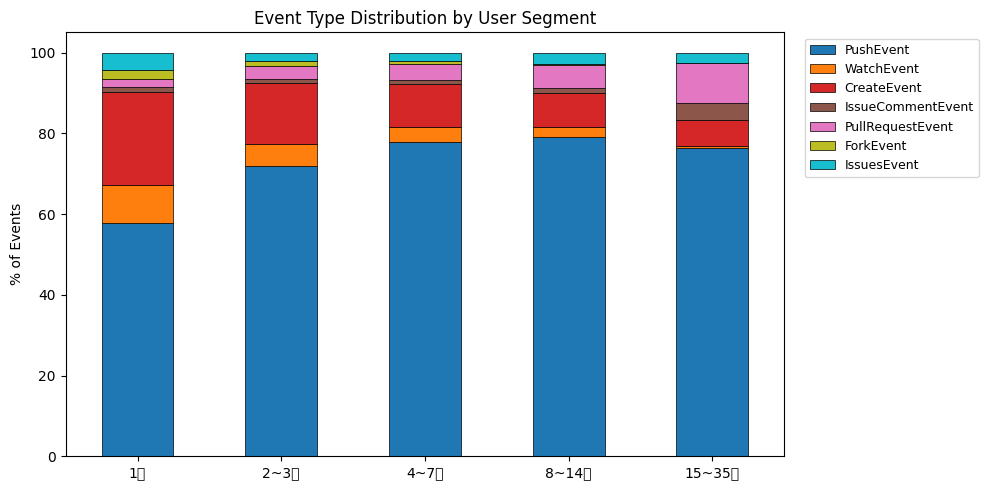

CPU times: user 5.07 s, sys: 1.36 s, total: 6.43 s
Wall time: 7.04 s


In [6]:
%%time
# 세그먼트별 top event type 분포
segment_map = user_stats.set_index("actor_id")["segment"]
df_seg = df.merge(segment_map, on="actor_id")

TOP_TYPES = ["PushEvent", "WatchEvent", "CreateEvent", "IssueCommentEvent",
             "PullRequestEvent", "ForkEvent", "IssuesEvent"]

seg_type = (
    df_seg[df_seg["type"].isin(TOP_TYPES)]
    .groupby(["segment", "type"])["cnt"]
    .sum()
    .reset_index()
)

# 세그먼트 내 비율로 변환
seg_totals = seg_type.groupby("segment")["cnt"].transform("sum")
seg_type["pct"] = seg_type["cnt"] / seg_totals * 100

# 피벗해서 stacked bar
pivot = seg_type.pivot_table(index="segment", columns="type", values="pct", fill_value=0)
pivot = pivot[TOP_TYPES]

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot.bar(stacked=True, ax=ax, colormap="tab10", edgecolor="black", linewidth=0.5)
ax.set_title("Event Type Distribution by User Segment")
ax.set_ylabel("% of Events")
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 5. WAU (Weekly Active Users) 추이

주별 활성 유저 수와, 신규/복귀 유저 비율을 확인합니다.

      week     wau  new_users  returning_users    new_pct
2026-02-15 2376903    2376903                0 100.000000
2026-02-22 2554095    1455466          1098629  56.985586
2026-03-01 2612778    1194818          1417960  45.729794
2026-03-08 2681235    1070206          1611029  39.914666
2026-03-15 2626728     930945          1695783  35.441241


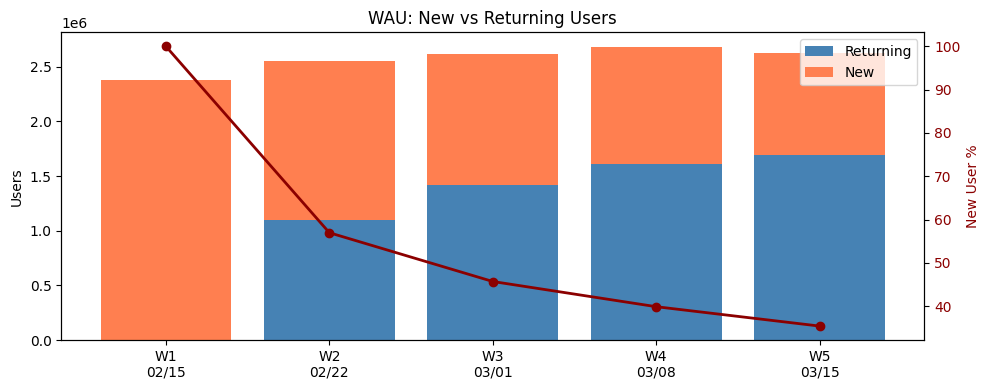

CPU times: user 13.6 s, sys: 373 ms, total: 14 s
Wall time: 14 s


In [7]:
%%time
# WAU + 신규/복귀 유저
weeks = sorted(df["week"].unique())
first_week = df.groupby("actor_id")["week"].min()

wau_data = []
for w in weeks:
    active = set(df[df["week"] == w]["actor_id"].unique())
    new = set(first_week[first_week == w].index)
    returning = active - new
    wau_data.append({
        "week": w,
        "wau": len(active),
        "new_users": len(new),
        "returning_users": len(returning),
    })

wau = pd.DataFrame(wau_data)
wau["new_pct"] = wau["new_users"] / wau["wau"] * 100

print(wau.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.bar(range(len(wau)), wau["returning_users"], label="Returning", color="steelblue")
ax1.bar(range(len(wau)), wau["new_users"], bottom=wau["returning_users"], label="New", color="coral")
ax1.set_xticks(range(len(wau)))
ax1.set_xticklabels([f"W{i+1}\n{w.strftime('%m/%d')}" for i, w in enumerate(wau["week"])])
ax1.set_ylabel("Users")
ax1.set_title("WAU: New vs Returning Users")
ax1.legend()

# 신규 비율 라인
ax2 = ax1.twinx()
ax2.plot(range(len(wau)), wau["new_pct"], color="darkred", marker="o", linewidth=2, label="New %")
ax2.set_ylabel("New User %", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")

plt.tight_layout()
plt.show()